In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [118]:
df = pd.read_csv("data/train.csv")

In [119]:
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

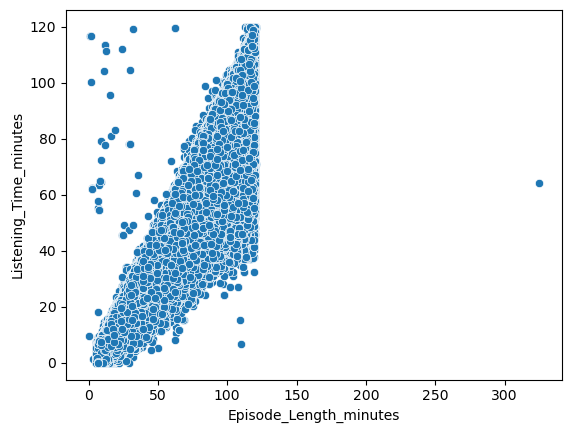

In [120]:
sns.scatterplot(data=df, x='Episode_Length_minutes', y='Listening_Time_minutes')

In [121]:
df[df['Episode_Length_minutes'] == df['Episode_Length_minutes'].max()]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
101637,101637,Home & Living,Episode 16,325.24,Lifestyle,50.69,Tuesday,Afternoon,15.01,0.0,Positive,64.31981


In [124]:
df = df[df['Episode_Length_minutes'] != df['Episode_Length_minutes'].max()]

<Axes: xlabel='Episode_Length_minutes', ylabel='Listening_Time_minutes'>

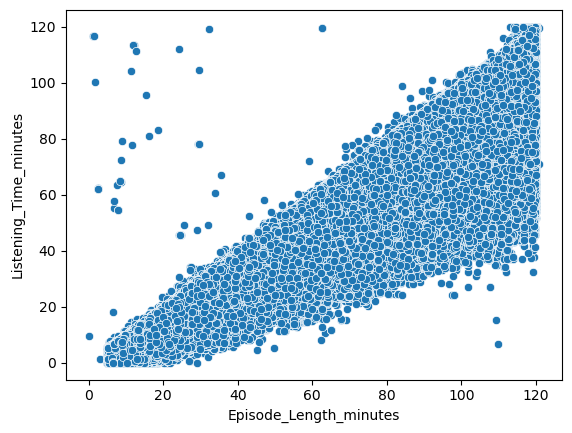

In [125]:
sns.scatterplot(data=df, x='Episode_Length_minutes', y='Listening_Time_minutes')

In [129]:
columns = ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']

In [132]:
from sklearn.linear_model import LinearRegression

In [164]:
X = df[columns]
means = X.mean()
X = X.fillna(means)
y = df['Listening_Time_minutes']

In [162]:
X.head()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads
0,64.504345,74.81,52.236511,0.0
1,119.800000,66.95,75.950000,2.0
2,73.900000,69.97,8.970000,0.0
3,67.170000,57.22,78.700000,2.0
4,110.510000,80.07,58.680000,3.0


In [138]:
y.head()

0    31.41998
1    88.01241
2    44.92531
3    46.27824
4    75.61031
Name: Listening_Time_minutes, dtype: float64

In [140]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [142]:
test = pd.read_csv("data/test.csv")
test.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


In [144]:
X_test = test[columns].fillna(means)
X_test.head()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads
0,78.96,38.11,53.330000,1.0
1,27.87,71.29,52.236511,0.0
2,69.10,67.89,97.510000,0.0
3,115.39,23.40,51.750000,2.0
4,72.32,58.10,11.300000,2.0


In [146]:
len(X_test)

250000

In [148]:
X_test.isnull().any(axis=1).sum()

0

In [150]:
y_test = model.predict(X_test)

In [152]:
out = test[["id"]]
out["Listening_Time_minutes"] = y_test

/var/folders/7s/yt4kf3pn5tlgk68sc4mn4pl80000gn/T/ipykernel_9923/2015173148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out["Listening_Time_minutes"] = y_test


In [154]:
out.head()


,id,Listening_Time_minutes
0,750000,56.144434
1,750001,20.540391
2,750002,51.163368
3,750003,81.381347
4,750004,50.468871


In [158]:
out.to_csv("output/linear-regerssion.csv", index=False)